In [ ]:
from pathlib import Path

from volcal.market_data.preprocessing import DataLoader
from volcal.heston.calibrator.pipeline import calibrate_heston, HestonCalibrationConfig
from volcal.heston.calibrator.checks import add_model_columns, plot_iv_smiles_vs_bid_ask
from volcal.utils import black_scholes as bs

# Notebook in /examples
p = Path.cwd().resolve()
REPO_ROOT = None
for parent in [p] + list(p.parents):
    if (parent / "pyproject.toml").exists():
        REPO_ROOT = parent
        break

DATA_DIR = REPO_ROOT / "data" / "spx"
BOOK_NAME = "SPX_17_10_25.xlsx"

loader = DataLoader(DATA_DIR, BOOK_NAME)
S0, act_date, df = loader.load_iv_table("Mid")

S0 = float(S0)
print("Spot:", S0, "| Current date:", act_date.date(), "| Data batch:", len(df))
df.head()

Spot: 6543.93 | Current date: 2025-10-17 | Data batch: 77


,Expiry,Exp Date,Risk Free,ImplFwd,Impl (Yld),Moneyness,IV
0,2M,2025-12-17,0.04005,6581.58,0.00570,0.8,0.3812
1,3M,2026-01-17,0.03916,6604.73,0.00244,0.8,0.3518
2,6M,2026-04-17,0.03707,6652.63,0.00400,0.8,0.3056
3,9M,2026-07-17,0.03550,6699.24,0.00411,0.8,0.2805
4,1Y,2026-10-17,0.03415,6742.53,0.00422,0.8,0.2687


In [37]:
from volcal.heston.calibrator.refine_data import refine_data

df_ref = refine_data(
    S0=S0,
    act_date=act_date,
    df=df,
    mn_low=0.8,
    mn_high=1.2,
    vega=True,
    trading_days=252,
    market_quote="otm",
)

df_ref.head()

,Expiry,Exp Date,Risk Free,ImplFwd,Impl (Yld),Moneyness,IV,To expiry,CalcFwd,Strike,Market call price,Market put price,Vega,Option type,Market price
0,2M,2025-12-17,0.04005,6598.568842,0.00570,0.8,0.3812,0.242063,6598.568842,5278.855073,1369.597725,62.616293,562.808789,put,62.616293
1,3M,2026-01-17,0.03916,6632.246708,0.00244,0.8,0.3518,0.365079,6632.246708,5305.797366,1401.393882,93.773221,807.880041,put,93.773221
2,6M,2026-04-17,0.03707,6702.105906,0.00400,0.8,0.3056,0.722222,6702.105906,5361.684725,1468.124823,163.114304,1356.464676,put,163.114304
3,9M,2026-07-17,0.03550,6770.288739,0.00411,0.8,0.2805,1.083333,6770.288739,5416.230991,1519.308285,216.336700,1787.567502,put,216.336700
4,1Y,2026-10-17,0.03415,6833.854716,0.00422,0.8,0.2687,1.448413,6833.854716,5467.083773,1572.164561,271.353858,2172.772652,put,271.353858


In [38]:
bounds = {
    "v0": (1e-4, 0.5),
    "kappa": (1e-3, 10.0),
    "theta": (1e-4, 0.5),
    "sigma": (1e-3, 1.5),
    "rho": (-0.95, -0.05),
}

cfg = HestonCalibrationConfig(
    mn_low=0.85,
    mn_high=1.15,
    pricer_method="laguerre",
    pricer_N=185,
    de_maxiter=60,
    de_popsize=12,
    lbfgs_maxiter=120,
)

In [25]:
from volcal.heston.calibrator.pipeline import calibrate_heston
res = calibrate_heston(S0=S0, act_date=act_date, df=df, bounds=bounds, cfg=cfg, verbose=True)
res["params"], res["loss_opt"]


Heston check — Put/Call parity
Status        : PASS
tol_abs       : 1e-10
max|diff|     :  1.819e-12
mean(diff)    :  1.056e-13
std(diff)     :  5.478e-13
DE     iter       time          loss          best         Δabs       Δrel  stale   params
------------------------------------------------------------------------------------------
LBFGS  iter       time          loss   params
---------------------------------------------

Initial seed: [ 0.044394  3.        0.044394  0.5      -0.5     ]

Starting Differential Evolution (global)
DE        1  00:00.604     1.590e-03     1.590e-03          inf        nan      0   v0= 0.0326734 kappa= 0.251162 theta= 0.371659 sigma= 0.991592 rho=-0.497981
DE        2  00:01.019     1.037e-03     1.037e-03    5.539e-04   3.48e-01      0   v0= 0.0419474 kappa= 0.194298 theta= 0.463786 sigma= 1.40961 rho=-0.439599
DE        3  00:01.356     3.916e-04     3.916e-04    6.450e-04   6.22e-01      0   v0= 0.0534122 kappa= 7.74988 theta= 0.0484683 sigma= 1.083

({'v0': 0.06646025167990684,
  'kappa': 1.511047297845444,
  'theta': 0.08092931391850719,
  'sigma': 1.3125564250622073,
  'rho': -0.821733255648418},
 1.4510819526047576e-05)


Model columns added
Added columns : 'Heston price', 'Heston IV'
IV NaNs       : 0 / 63

Plot — IV smiles vs bid/ask (mid ± bid/ask) + model IV


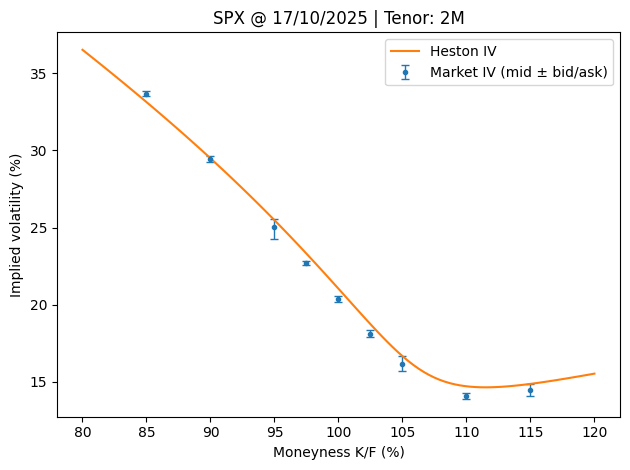

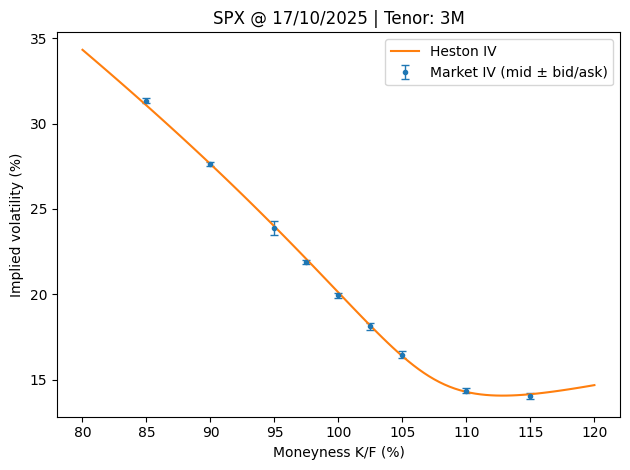

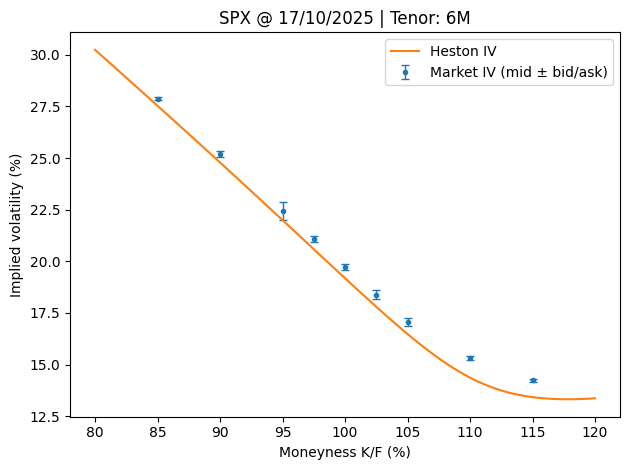

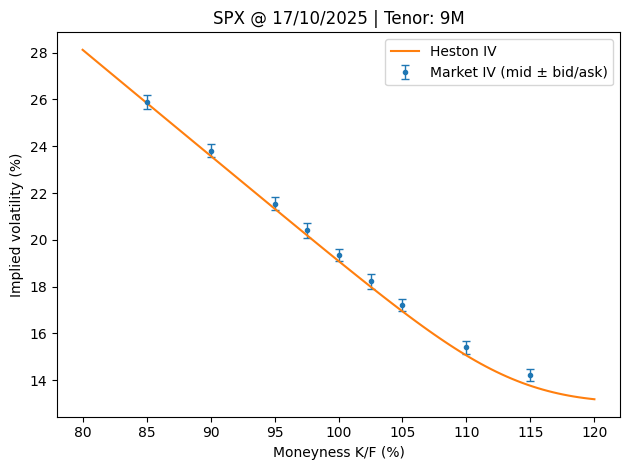

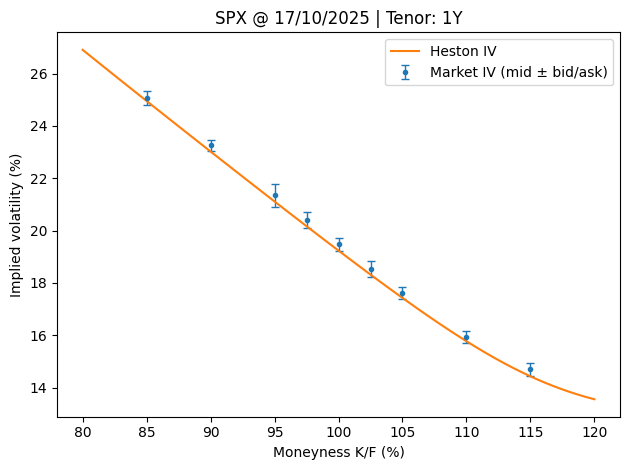

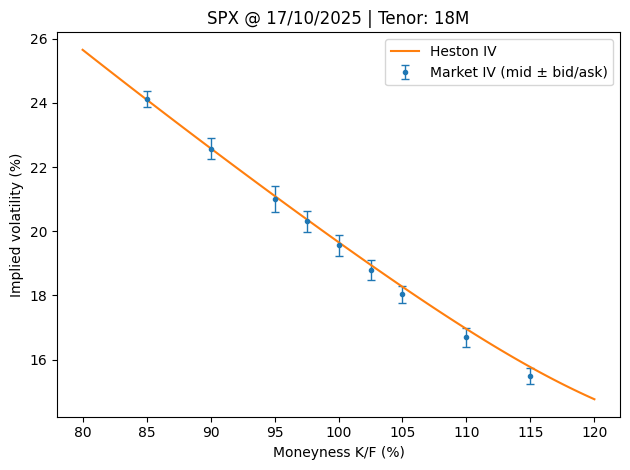

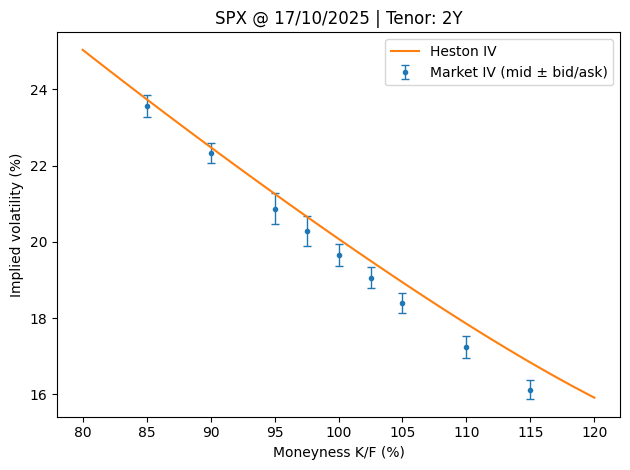

In [26]:
df_checked = add_model_columns(
    df=res["df_refined"],
    pricer=res["pricer"],
    bs=bs,
    S0=S0,
    heston_params=res["params"],
)

plot_iv_smiles_vs_bid_ask(
    df=df_checked,
    pricer=res["pricer"],
    bs=bs,
    loader=loader,
    S0=S0,
    act_date=act_date,
    heston_params=res["params"],
    title_prefix=f"SPX @ {act_date:%d/%m/%Y}",
)